# Naive Keyword Matching

This notebook builds and evaluates a deliberately naive baseline: for each job, every CV is scored by **how many of the job's keywords appear in the CV's skills**, and CVs are ranked from highest to lowest count. The goal is to establish a floor that later approaches (e.g. an LLM-as-judge) must beat, and to document honestly where keyword matching fails.

Input: `data/resume_clean.pkl`, produced by `01_eda.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_pickle("../data/resume_clean.pkl")
print(df.shape)

(9544, 35)


In [2]:
df["matched_words"] = [cv & job for cv, job in zip(df["cv_keywords"], df["job_keywords"])]
df["match_count"] = df["matched_words"].map(len)

count    9544.000000
mean        1.872171
std         2.038970
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max        19.000000
Name: match_count, dtype: float64
Share of pairs with zero matches: 0.31


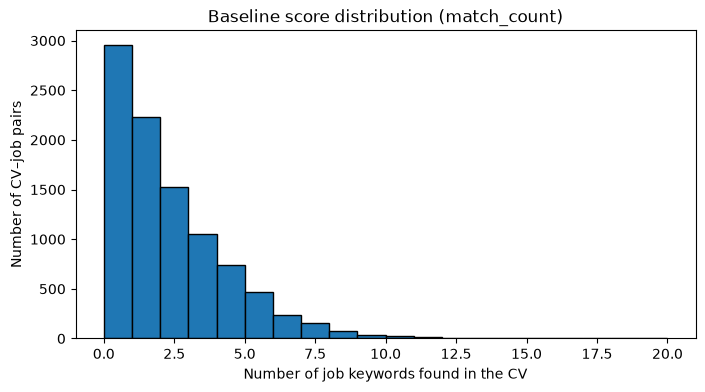

In [3]:
print(df["match_count"].describe())
print("Share of pairs with zero matches:", (df["match_count"] == 0).mean().round(3))

plt.figure(figsize=(8, 4))
plt.hist(df["match_count"], bins=range(0, 21), edgecolor="black")
plt.xlabel("Number of job keywords found in the CV")
plt.ylabel("Number of CV–job pairs")
plt.title("Baseline score distribution (match_count)")
plt.show()

In [4]:
df["baseline_rank"] = (df.groupby("job_position_name")["match_count"]
                         .rank(ascending=False, method="min"))

df[df["job_position_name"] == "Executive - VAT"].sort_values("baseline_rank")[
    ["baseline_rank", "match_count", "matched_words", "positions", "matched_score"]].head(5)

,baseline_rank,match_count,matched_words,positions,matched_score
1290,1.0,7,"{forms, documentation, management, software, o...","['Staff Accountant', 'Financial Aid Accounting...",0.816667
7500,1.0,7,"{maintenance, ms, management, software, coordi...","['Accountant', 'District Administrative Manage...",0.716667
4897,1.0,7,"{ms, management, tasks, software, office, tax,...","['Accountant', 'Tax Accountant', 'Accounting M...",0.926667
5872,1.0,7,"{maintenance, ms, management, coordination, of...","['Lead Accountant', 'Senior Accountant', 'Seni...",0.816667
3472,5.0,6,"{liaison, forms, documentation, management, co...","['Business Development & Marketing', 'Corporat...",0.850000


In [5]:
def tie_stats(group):
    counts = group["match_count"]
    return pd.Series({
        "distinct_scores": counts.nunique(),
        "max_match": counts.max(),
        "zero_match_%": round((counts == 0).mean() * 100, 1),
        "tied_at_10th": (counts == counts.nlargest(10).iloc[-1]).sum(),
    })

ties = df.groupby("job_position_name").apply(tie_stats, include_groups=False)
ties.sort_values("distinct_scores")

,distinct_scores,max_match,zero_match_%,tied_at_10th
job_position_name,,,,
Head of Internal Control & Compliance (ICC) - SEVP/DMD,6.0,5.0,62.2,12.0
Mechanical Engineer,6.0,5.0,72.4,6.0
Sr.Officer / Executive - Internal Audit,6.0,6.0,43.4,13.0
Business Development Executive,7.0,6.0,43.4,10.0
Manager- Human Resource Management (HRM),7.0,6.0,46.6,11.0
Mechanical Designer,7.0,6.0,54.3,8.0
"Executive/ Senior Executive- Trade Marketing, Hygiene Products",7.0,8.0,43.4,12.0
DevOps Engineer,7.0,6.0,25.6,14.0
Marketing Officer,7.0,9.0,37.8,9.0


In [6]:
from scipy.stats import spearmanr

df["n_cv_keywords"] = df["cv_keywords"].map(len)
corr = spearmanr(df["n_cv_keywords"], df["match_count"]).correlation
print("Spearman (CV keyword count vs match count):", round(corr, 3))

Spearman (CV keyword count vs match count): 0.48


### How the baseline behaves

**Scores are very low and coarse.** The median CV matches just **1** job keyword (mean 1.87, max 19), and **31% of all CV–job pairs match zero keywords**. Scores are small whole numbers, so each job's ~341 CVs are squeezed into only **6 to 17 distinct scores**.

**Ties are heavy.** For most jobs, several CVs share 10th place (up to **23 CVs for ML Engineer**, 15 for the Generative AI Intern, 14 for DevOps). The baseline's "top 10" is therefore partly arbitrary. For some jobs most applicants score zero (**72% for Mechanical Engineer**, 62% for Head of ICC), so the baseline cannot distinguish between them at all.

**It sometimes looks sensible.** For Executive – VAT, the top 5 CVs are all accountants (matched_score 0.72–0.93). The baseline clearly picks up genuine domain signal when a job's vocabulary is distinctive (`ledger`, `tax`).

**But for partly the wrong reasons.** Most of those accountants' matched words are generic: `management`, `office`, `software`, `ms`, `tasks`, `coordination`. None of the top 5 actually matched `vat` or `mushak`, the most job-specific words.

**Length bias.** CVs that list more skills match more keywords (Spearman **0.48** between a CV's keyword count and its match count). A candidate with a long, padded skills list is rewarded regardless of fit. This is exactly the weakness keyword stuffing exploits.